In [1]:
import pandas as pd
import trxtools.methods as ttm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from trxtools.utils.names import cleanNames

## Load data

Load TPM tables

In [2]:
df00_uniq = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_umitools_uniq_TPM.txt', sep='\t', index_col=0)
df00_uniq = df00_uniq[[col for col in df00_uniq.columns if 'NIH3T3' in col]]
df00_uniq = cleanNames(df00_uniq, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
df00_uniq = df00_uniq[['anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]

df01_multi = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_umitools_multimappers_TPM.txt', sep='\t', index_col=0)
df01_multi = df01_multi[[col for col in df01_multi.columns if 'NIH3T3' in col]]
df01_multi = cleanNames(df01_multi, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
df01_multi = df01_multi[['anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]

## Basic QC

### Number of mapped reads

In [3]:
summary_uniq = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_umitools_uniq.list.summary', sep='\t')
summary_uniq = summary_uniq[['Status']+[col for col in summary_uniq.columns if 'NIH3T3' in col]]
summary_uniq = cleanNames(summary_uniq, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
summary_uniq = summary_uniq[['Status', 'anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]

summary_multi = pd.read_csv('../03a_FeatureCounts_umitools/featureCounts_umitools_multimappers.list.summary', sep='\t')
summary_multi = summary_multi[['Status']+[col for col in summary_multi.columns if 'NIH3T3' in col]]
summary_multi = cleanNames(summary_multi, ['02c_alignment_all_umitools/', '_all_dedup.bam', 'VL260225_'])
summary_multi = summary_multi[['Status', 'anti-Igf2bp2_NIH3T3_noUV_1', 'anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']]

/tmp/ipykernel_776/1560417554.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_reads_uniq, x='Library', y='Read count', palette='tab20', ax=axes[0])
/tmp/ipykernel_776/1560417554.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=assigned_uniq, x='Library', y='Read count', palette='tab20', ax=axes[1])


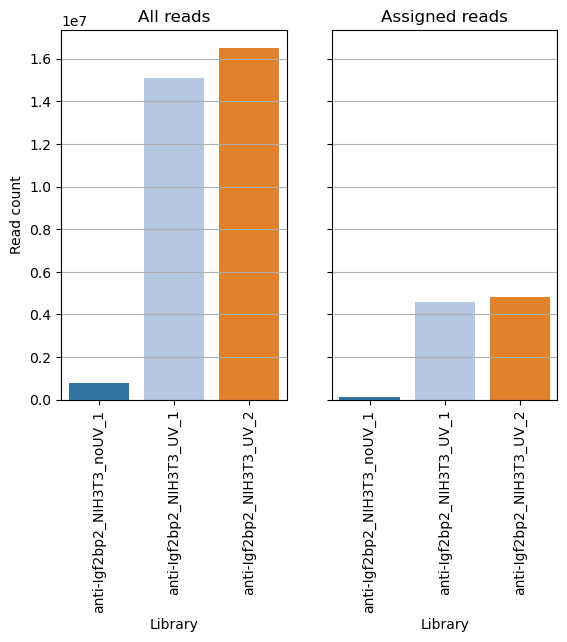

In [4]:
fig, axes = plt.subplots(1, 2, sharey=True)

all_reads_uniq = summary_uniq.drop(columns=['Status']).sum(numeric_only=True).reset_index()
all_reads_uniq.columns = ['Library', 'Read count']

assigned_uniq = summary_uniq.loc[
    summary_uniq['Status'].astype(str).str.lower() == 'assigned',
    summary_uniq.columns != 'Status'
 ]
if assigned_uniq.empty:
    assigned_uniq = summary_uniq.drop(columns=['Status']).iloc[[0]]
assigned_uniq = assigned_uniq.T.reset_index()
assigned_uniq.columns = ['Library', 'Read count']

sns.barplot(data=all_reads_uniq, x='Library', y='Read count', palette='tab20', ax=axes[0])
sns.barplot(data=assigned_uniq, x='Library', y='Read count', palette='tab20', ax=axes[1])
plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)
plt.savefig("00_qc_readcounts_unique.png", bbox_inches='tight', dpi=300)
plt.savefig("00_qc_readcounts_unique.svg", bbox_inches='tight')

/tmp/ipykernel_776/1811565341.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=all_reads_multi, x='Library', y='Read count', palette='tab20', ax=axes[0])
/tmp/ipykernel_776/1811565341.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=assigned_multi, x='Library', y='Read count', palette='tab20', ax=axes[1])


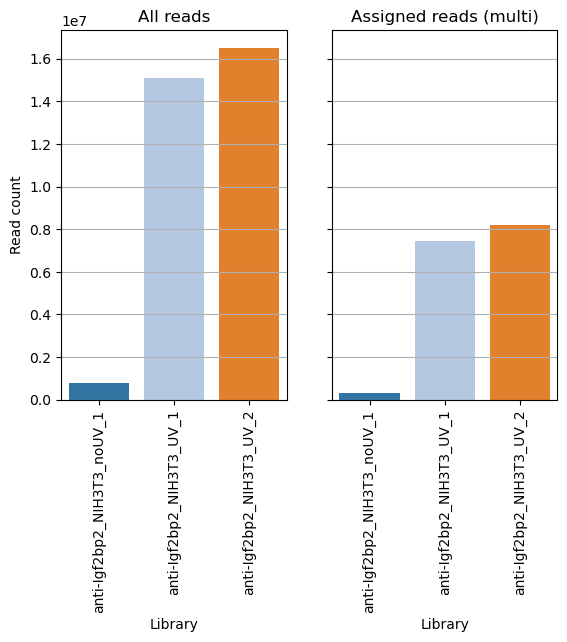

In [5]:
fig, axes = plt.subplots(1, 2, sharey=True)

all_reads_multi = summary_multi.drop(columns=['Status']).sum(numeric_only=True).reset_index()
all_reads_multi.columns = ['Library', 'Read count']

assigned_multi = summary_multi.loc[
    summary_multi['Status'].astype(str).str.lower() == 'assigned',
    summary_multi.columns != 'Status'
 ]
if assigned_multi.empty:
    assigned_multi = summary_multi.drop(columns=['Status']).iloc[[0]]
assigned_multi = assigned_multi.T.reset_index()
assigned_multi.columns = ['Library', 'Read count']

sns.barplot(data=all_reads_multi, x='Library', y='Read count', palette='tab20', ax=axes[0])
sns.barplot(data=assigned_multi, x='Library', y='Read count', palette='tab20', ax=axes[1])
# plt.title("Read count per library")
axes[0].set_ylabel("Read count")
axes[0].set_title("All reads")
axes[1].set_title("Assigned reads (multi)")
for ax in axes:
    ax.grid(axis='y')
    ax.set_xlabel("Library")
    ax.tick_params(axis='x', rotation=90)
plt.savefig("00_NIH3T3_qc_readcounts_multi.png", bbox_inches='tight', dpi=300)
plt.savefig("00_NIH3T3_qc_readcounts_multi.svg", bbox_inches='tight')

### Sample correlations

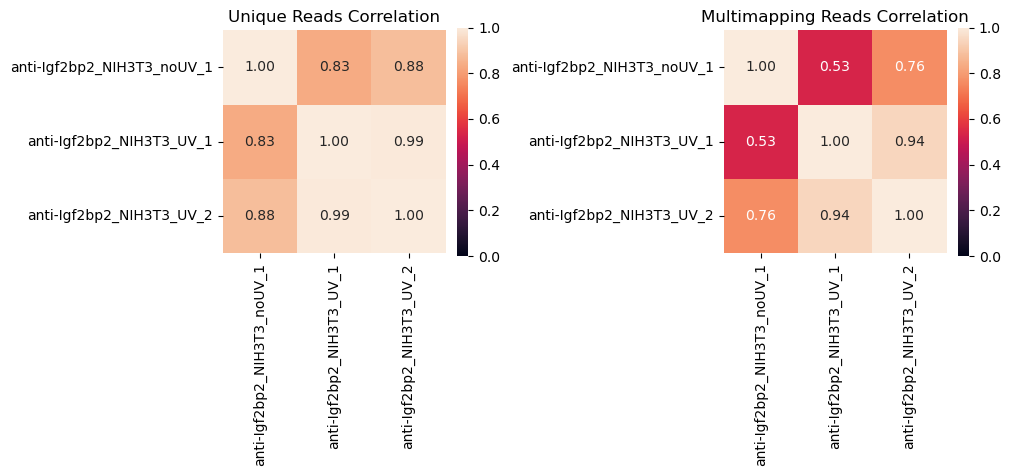

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout='constrained')

sns.heatmap(df00_uniq.corr('pearson', numeric_only=True), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .7}, ax=axes[0])
axes[0].set_title("Unique Reads Correlation")

sns.heatmap(df01_multi.corr('pearson', numeric_only=True), annot=True, fmt=".2f", square=True, vmin=0, vmax=1, cbar_kws={"shrink": .7}, ax=axes[1])
axes[1].set_title("Multimapping Reads Correlation")
plt.savefig("00_NIH3T3_qc_correlation_heatmaps.png", dpi=300)
plt.savefig("00_NIH3T3_qc_correlation_heatmaps.svg")

## Read classes
Look at what kinds of loci reads map to

Get gene types from GTF file

In [7]:
#Run once to generate gtf_classes.csv, then comment out to save time on subsequent runs

# gtf = pd.read_csv("../references/gencode.vM38.annotation.gtf", sep="\t", header=None, skiprows=5)
# gtf = gtf[gtf[2].isin(['gene'])]
# gtf_classes = gtf[8].str.split("; ", expand=True)[[0,1,2]]
# gtf_classes[0] = gtf_classes[0].str.replace('gene_id "', '', regex=False)
# gtf_classes[0] = gtf_classes[0].str.replace('"', '', regex=False)
# gtf_classes[1] = gtf_classes[1].str.replace('gene_type "', '', regex=False)
# gtf_classes[1] = gtf_classes[1].str.replace('"', '', regex=False)
# gtf_classes[2] = gtf_classes[2].str.replace('gene_name "', '', regex=False)
# gtf_classes[2] = gtf_classes[2].str.replace('"', '', regex=False)
# gtf_classes = gtf_classes.rename(columns={0: 'gene_id', 1: 'gene_type', 2: 'gene_name'})
# gtf_classes = gtf_classes.set_index('gene_id')
# gtf_classes.head()
# gtf_classes.to_csv("../references/gtf_classes_mouse.csv")

In [8]:
gtf_classes = pd.read_csv("../references/gtf_classes_mouse.csv", index_col='gene_id')

Add gene_class info to df's, also fix tRNA class by looking at gene_name

In [9]:
for df_name in [
    "df00_uniq", "df01_multi"
]:
    df = globals()[df_name].drop(columns=gtf_classes.columns, errors='ignore')
    df = pd.concat([df, gtf_classes], axis=1)
    df.loc[df.index.str.contains('tRNA'), 'gene_type'] = 'tRNA'
    mask = df.filter(regex=r'^gene_type$').eq('tRNA').any(axis=1).to_numpy()
    gene_name_positions = [col_idx for col_idx, col in enumerate(df.columns) if col == 'gene_name']
    for pos in gene_name_positions:
        df.iloc[mask, pos] = df.index[mask]
    globals()[df_name] = df

In [10]:
df00_uniq.to_csv("00_NIH3T3_allsamples_featureCounts_TPM_geneclasses_unique.csv")
df01_multi.to_csv("00_NIH3T3_allsamples_featureCounts_TPM_geneclasses_multimapping.csv")

Prepare df for plotting

In [11]:
# Calculate percentages for barplot
bar_uniq = df00_uniq.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1) # type: ignore
bar_multi = df01_multi.reset_index().groupby('gene_type').agg('sum', numeric_only=True).T.apply(lambda x: x/sum(x), axis=1)

#filter out some classes and sum them into 'other'
keep = [
    'Mt_rRNA', 'Mt_tRNA', 'lncRNA', 'miRNA',
    'polymorphic_pseudogene',
    'protein_coding', 'rRNA', 'rRNA_pseudogene',
    'snRNA', 'snoRNA', 'tRNA'
]

bar_uniq_keep = bar_uniq.loc[:,bar_uniq.columns.isin(keep)]
# bar_uniq_keep['rRNA'] = bar_uniq_keep['rRNA'] + bar_uniq_keep['rRNA_pseudogene']
# bar_uniq_keep = bar_uniq_keep.drop(columns=['rRNA_pseudogene'])
bar_uniq_plot = pd.concat([bar_uniq_keep, pd.DataFrame(bar_uniq.loc[:,~bar_uniq.columns.isin(keep)].sum(axis=1))], axis=1)
bar_uniq_plot = bar_uniq_plot.rename({0: 'other'}, axis=1)

bar_multi_keep = bar_multi.loc[:,bar_multi.columns.isin(keep)]
# bar_multi_keep['rRNA'] = bar_multi_keep['rRNA'] + bar_multi_keep['rRNA_pseudogene']
# bar_multi_keep = bar_multi_keep.drop(columns=['rRNA_pseudogene'])
bar_multi_plot = pd.concat([bar_multi_keep, pd.DataFrame(bar_multi.loc[:,~bar_multi.columns.isin(keep)].sum(axis=1))], axis=1)
bar_multi_plot = bar_multi_plot.rename({0: 'other'}, axis=1)

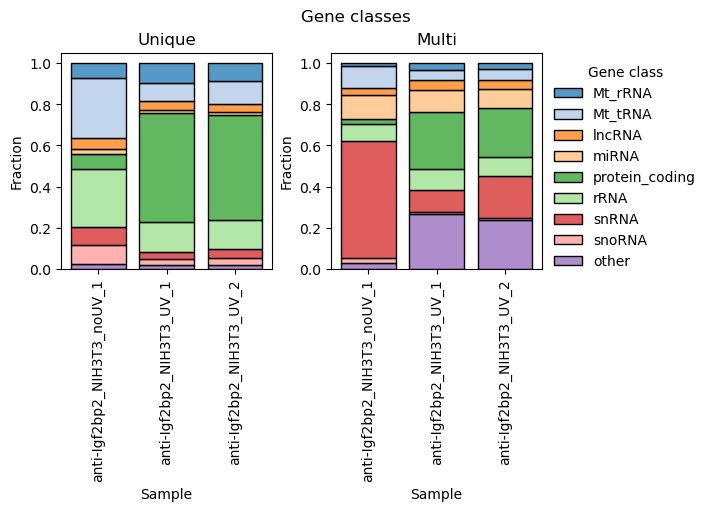

In [12]:
fig, axes = plt.subplots(1,2, figsize=(7, 5), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[0])
sns.histplot(bar_multi_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=axes[1])
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_bbox_to_anchor((1, 1.0))
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel('Fraction')
    legend.set_frame_on(False)
    ax.set_xlabel('Sample')
axes[0].set_title("Unique")
axes[1].set_title("Multi")
plt.suptitle("Gene classes")
plt.savefig('00_NIH3T3_read_classes_unique_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('00_NIH3T3_read_classes_unique_comparison.svg', bbox_inches='tight')

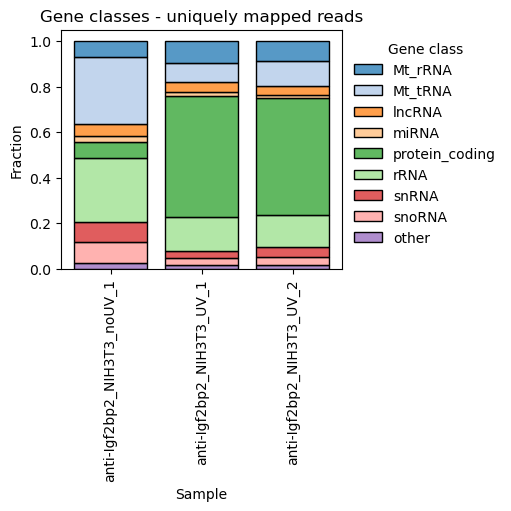

In [13]:
fig, ax = plt.subplots(figsize=(5, 5), layout='constrained')
sns.histplot(bar_uniq_plot.reset_index().melt('index', var_name='Gene class'), x='index', hue='Gene class', weights='value',
             multiple='stack', palette='tab20', shrink=0.8, ax=ax)
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, 1))
legend.set_frame_on(False)
ax.set_ylabel('Fraction')
ax.set_xlabel('Sample')
ax.tick_params(axis='x', rotation=90)
plt.title("Gene classes - uniquely mapped reads")
plt.savefig('00_NIH3T3_read_classes_unique_TPMonly.png', dpi=300, bbox_inches='tight')
plt.savefig('00_NIH3T3_read_classes_unique_TPMonly.svg', bbox_inches='tight')

### Top hits table

#### mRNA

In [14]:
df_hits = df00_uniq.copy().assign(mean=lambda x: x[['anti-Igf2bp2_NIH3T3_UV_1', 'anti-Igf2bp2_NIH3T3_UV_2']].mean(axis=1))
df_hits = df_hits.sort_values('mean', ascending=False)
df_hits.to_csv("00_NIH3T3_uniq_hits_all.csv", index=False)
df_hits_mrna = df_hits.loc[df_hits['gene_type'] == 'protein_coding']
df_hits_mrna.to_csv("00_NIH3T3_uniq_hits_mRNA.csv", index=False)
df_hits_other = df_hits.loc[~df_hits['gene_type'].isin(keep)]
df_hits_other.to_csv("00_NIH3T3_uniq_hits_other.csv", index=False)
df_hits_mrna.head(20)

,anti-Igf2bp2_NIH3T3_noUV_1,anti-Igf2bp2_NIH3T3_UV_1,anti-Igf2bp2_NIH3T3_UV_2,gene_type,gene_name,mean
ENSMUSG00000064351.1,3377.029111,5720.264408,6013.693704,protein_coding,mt-Co1,5866.979056
ENSMUSG00000064367.1,953.492320,5301.715082,5741.333749,protein_coding,mt-Nd5,5521.524416
ENSMUSG00000064370.1,1370.804841,4725.271858,5533.267400,protein_coding,mt-Cytb,5129.269629
ENSMUSG00000031375.19,165.294154,5192.098661,4708.009528,protein_coding,Bgn,4950.054094
ENSMUSG00000064368.1,954.183595,4774.638483,4692.193741,protein_coding,mt-Nd6,4733.416112
ENSMUSG00000064341.1,1583.219765,4081.811629,4539.268053,protein_coding,mt-Nd1,4310.539841
ENSMUSG00000060802.9,123.394008,4154.104789,4098.785611,protein_coding,B2m,4126.445200
ENSMUSG00000064345.1,329.420527,3459.337819,4223.848757,protein_coding,mt-Nd2,3841.593288
ENSMUSG00000024529.15,156.703102,3783.464387,3601.829965,protein_coding,Lox,3692.647176
ENSMUSG00000040152.9,162.118735,3556.858724,3311.649492,protein_coding,Thbs1,3434.254108


#### Other

In [15]:
df_hits_other = df_hits.loc[~df_hits['gene_type'].isin(keep)]
df_hits_other.to_csv("00_NIH3T3_uniq_hits_other.csv", index=False)
df_hits_other.head(20)

,anti-Igf2bp2_NIH3T3_noUV_1,anti-Igf2bp2_NIH3T3_UV_1,anti-Igf2bp2_NIH3T3_UV_2,gene_type,gene_name,mean
ENSMUSG00002076161.1,7480.684076,3963.002912,3746.317397,misc_RNA,Rn7sk,3854.660154
ENSMUSG00002074846.1,10471.712172,3906.166019,3213.152859,misc_RNA,Vaultrc5,3559.659439
ENSMUSG00000089417.3,807.837027,440.636265,405.185942,scaRNA,Gm22009,422.911104
ENSMUSG00000088025.3,142.304967,195.437378,213.211637,ribozyme,Rprl3,204.324508
ENSMUSG00000066407.4,19.651638,180.526230,158.832889,processed_pseudogene,Gm10263,169.679560
ENSMUSG00000088208.3,1560.571279,120.391979,208.551588,scaRNA,Gm23751,164.471784
ENSMUSG00000088254.3,349.362459,139.942814,172.279060,scaRNA,Gm24289,156.110937
ENSMUSG00000100215.2,14.887605,152.664888,113.165569,processed_pseudogene,Gm8292,132.915228
ENSMUSG00000084289.2,0.000000,105.777088,134.059568,processed_pseudogene,Fth1-ps,119.918328
ENSMUSG00000088958.3,990.082542,81.722330,112.586018,scaRNA,Scarna8,97.154174


#### All

In [16]:
df_hits.to_csv("00_NIH3T3_uniq_hits_all.csv", index=False)
df_hits.head(20)

,anti-Igf2bp2_NIH3T3_noUV_1,anti-Igf2bp2_NIH3T3_UV_1,anti-Igf2bp2_NIH3T3_UV_2,gene_type,gene_name,mean
ENSMUSG00000119584.1,179256.101690,119797.898047,112520.026662,rRNA,Rn18s-rs5,116158.962355
ENSMUSG00000064339.1,43027.398760,64755.219793,56747.187676,Mt_rRNA,mt-Rnr2,60751.203734
ENSMUSG00000064337.1,28613.196957,31950.702802,30411.687013,Mt_rRNA,mt-Rnr1,31181.194908
ENSMUSG00000136525.1,41518.828157,31783.768613,26282.331405,lncRNA,Gm72623,29033.050009
ENSMUSG00000064344.1,114235.828015,24103.628536,32210.520750,Mt_tRNA,mt-Tm,28157.074643
ENSMUSG00000064347.1,13756.146829,18737.125855,18785.359856,Mt_tRNA,mt-Ta,18761.242855
ENSMUSG00002075795.1,96279.749669,18058.296320,18972.557983,rRNA,Gm54867,18515.427151
ENSMUSG00000064338.1,34176.762308,12905.161208,16351.895297,Mt_tRNA,mt-Tv,14628.528252
ENSMUSG00000098973.3,18309.575222,10720.984822,9320.594355,miRNA,Mir6236,10020.789589
ENSMUSG00000064365.1,34873.331065,4696.385950,10258.758659,Mt_tRNA,mt-Ts2,7477.572305
